## Temporal Convolutional Network

In [22]:
!pip install widgetsnbextension
!jupyter nbextension enable widgetsnbextension --user --py


[notice] A new release of pip is available: 23.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip
usage: jupyter [-h] [--version] [--config-dir] [--data-dir] [--runtime-dir]
               [--paths] [--json] [--debug]
               [subcommand]

Jupyter: Interactive Computing

positional arguments:
  subcommand     the subcommand to launch

options:
  -h, --help     show this help message and exit
  --version      show the versions of core jupyter packages and exit
  --config-dir   show Jupyter config dir
  --data-dir     show Jupyter data dir
  --runtime-dir  show Jupyter runtime dir
  --paths        show all Jupyter paths. Add --json for machine-readable
                 format.
  --json         output paths as machine-readable json
  --debug        output debug information about paths

Available subcommands: console dejavu events execute kernel kernelspec lab
labextension labhub migrate nbconvert notebook run server troubleshoot trust

Jupyter command `ju

In [1]:
%matplotlib inline

import warnings

import matplotlib.pyplot as plt
import pandas as pd

from darts import TimeSeries, concatenate
from darts.dataprocessing.transformers import Scaler
from darts.datasets import AirPassengersDataset, EnergyDataset, SunspotsDataset
from darts.models import TCNModel
from darts.utils.callbacks import TFMProgressBar
from darts.utils.missing_values import fill_missing_values
from darts.utils.timeseries_generation import datetime_attribute_timeseries

warnings.filterwarnings("ignore")

def generate_torch_kwargs():
    # run torch models on CPU, and disable progress bars for all model stages except training.
    return {
        "pl_trainer_kwargs": {
            "accelerator": "cpu",
            "callbacks": [TFMProgressBar(enable_train_bar_only=True)],
        }
    }

The StatsForecast module could not be imported. To enable support for the AutoARIMA, AutoETS and Croston models, please consider installing it.
The `XGBoost` module could not be imported. To enable XGBoost support in Darts, follow the detailed instructions in the installation guide: https://github.com/unit8co/darts/blob/master/INSTALL.md
The `XGBoost` module could not be imported. To enable XGBoost support in Darts, follow the detailed instructions in the installation guide: https://github.com/unit8co/darts/blob/master/INSTALL.md


## Daily energy production

<Axes: xlabel='time'>

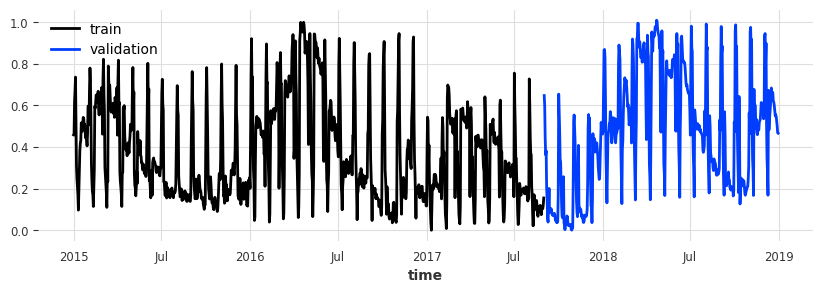

In [2]:
df3 = EnergyDataset().load().to_dataframe()
df3_day_avg = (
    df3.groupby(df3.index.astype(str).str.split(" ").str[0]).mean().reset_index()
)
series_en = fill_missing_values(
    TimeSeries.from_dataframe(
        df3_day_avg, "time", ["generation hydro run-of-river and poundage"]
    ),
    "auto",
)

# create train and test splits
train_en, val_en = series_en.split_after(pd.Timestamp("20170901"))

# scale the data
scaler_en = Scaler()
train_en_transformed = scaler_en.fit_transform(train_en)
val_en_transformed = scaler_en.transform(val_en)
series_en_transformed = scaler_en.transform(series_en)

# add the day as a covariate (scaling not required as one-hot-encoded)
day_series = datetime_attribute_timeseries(
    series_en_transformed, attribute="day", one_hot=True
)

plt.figure(figsize=(10, 3))
train_en_transformed.plot(label="train")
val_en_transformed.plot(label="validation")

In [3]:
model_name = "TCN_energy"
model_en = TCNModel(
    input_chunk_length=365,
    output_chunk_length=7,
    n_epochs=50,
    dropout=0.2,
    dilation_base=2,
    weight_norm=True,
    kernel_size=5,
    num_filters=8,
    nr_epochs_val_period=1,
    random_state=0,
    save_checkpoints=True,
    model_name=model_name,
    force_reset=True,
    **generate_torch_kwargs(),
)

In [4]:
model_en.fit(
    series=train_en_transformed,
    past_covariates=day_series,
    val_series=val_en_transformed,
    val_past_covariates=day_series,
)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | res_blocks      | ModuleList       | 5.0 K  | train
-------------------------------------------------------------
5.0 K     Trainable params
0         Non-trainable params
5.0 K     Total params
0.020     Total estimated model params size (MB)
74        Modules in train mode
0         Modules in eval mode


Training: 0it [00:00, ?it/s]

`Trainer.fit` stopped: `max_epochs=50` reached.


TCNModel(output_chunk_shift=0, kernel_size=5, num_filters=8, num_layers=None, dilation_base=2, weight_norm=True, dropout=0.2, input_chunk_length=365, output_chunk_length=7, n_epochs=50, nr_epochs_val_period=1, random_state=0, save_checkpoints=True, model_name=TCN_energy, force_reset=True, pl_trainer_kwargs={'accelerator': 'cpu', 'callbacks': [<darts.utils.callbacks.TFMProgressBar object at 0x000001F469831240>]})

In [5]:
model_en = TCNModel.load_from_checkpoint(model_name=model_name, best=True)

In [6]:
backtest_en = model_en.historical_forecasts(
    series=series_en_transformed,
    past_covariates=day_series,
    start=val_en_transformed.start_time(),
    forecast_horizon=7,
    stride=7,
    last_points_only=False,
    retrain=False,
    verbose=True,
)
backtest_en = concatenate(backtest_en)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Generating TimeSeries:   0%|          | 0/69 [00:00<?, ?it/s]

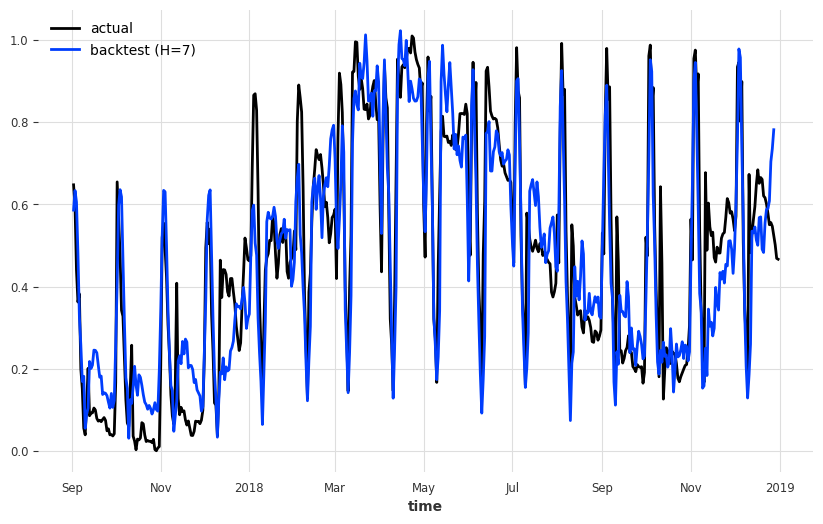

In [7]:
plt.figure(figsize=(10, 6))
val_en_transformed.plot(label="actual")
backtest_en.plot(label="backtest (H=7)")
plt.legend()